In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# cek versi tensorflow
print(tf.__version__)

2.19.0


In [3]:
# cek keras
print(keras.__version__)

3.13.2


In [4]:
# check python
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [5]:
# Cek GPU
device = '/GPU:0' if tf.config.list_physical_devices('GPU') else '/CPU:0'
print(f"Using device: {device}")

Using device: /GPU:0


# Data Augmentation & Preprocessing

In [6]:
# Data augmentation & preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

valid_test_datagen = ImageDataGenerator(rescale=1./255)

In [7]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"naubass","key":"971f5810f2bafc6d58b33c053aefdf0e"}'}

In [8]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [9]:
!kaggle datasets download -d youssefmohmmed/dogs-skin-diseases-image-dataset

Dataset URL: https://www.kaggle.com/datasets/youssefmohmmed/dogs-skin-diseases-image-dataset
License(s): apache-2.0
100% 219M/219M [00:01<00:00, 120MB/s]



In [10]:
!unzip dogs-skin-diseases-image-dataset.zip -d /content/

Archive:  dogs-skin-diseases-image-dataset.zip
  inflating: /content/test/Dermatitis/1000010494_x16_jpg.rf.ea6148c3096cad322d093d8c9202b9cd.jpg  
  inflating: /content/test/Dermatitis/1000010536_x4_jpg.rf.a7cad2e3b94215381440871281245960.jpg  
  inflating: /content/test/Dermatitis/1000010626_x4_jpg.rf.dd018753531153596ff7da1edd7a61ac.jpg  
  inflating: /content/test/Dermatitis/1000010648_x16_jpg.rf.ac9d9b488cddf942639fd11874d7b269.jpg  
  inflating: /content/test/Dermatitis/1000010652_x16_jpg.rf.49ca91eb9622ee207a9af19717b70778.jpg  
  inflating: /content/test/Dermatitis/1000010673_x16_jpg.rf.fa6dbd65df4998a3ae78df33e6de29f0.jpg  
  inflating: /content/test/Dermatitis/1000010680_x16_jpg.rf.022565ad71fbc7c3f9527a89d399c72a.jpg  
  inflating: /content/test/Dermatitis/1000010693_x16_jpg.rf.bac3541b5be276ac003e21592bcf099c.jpg  
  inflating: /content/test/Dermatitis/1000010721_x16_jpg.rf.d3bfcecb66b5a40adda22aafd6c99f21.jpg  
  inflating: /content/test/Dermatitis/1000010725_x16_jpg.rf.358d

In [11]:
# Load datasets menggunakan ImageDataGenerator
data_dir = '/content'
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_generator = train_datagen.flow_from_directory(
    os.path.join(data_dir, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_generator = valid_test_datagen.flow_from_directory(
    os.path.join(data_dir, 'valid'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = valid_test_datagen.flow_from_directory(
    os.path.join(data_dir, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 3022 images belonging to 6 classes.
Found 860 images belonging to 6 classes.
Found 433 images belonging to 6 classes.


In [12]:
class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

print("Class Names:", class_names)
print("Number of Classes:", num_classes)

Class Names: ['Dermatitis', 'Fungal_infections', 'Healthy', 'Hypersensitivity', 'demodicosis', 'ringworm']
Number of Classes: 6


In [13]:
# Load ResNet50 dan modifikasi untuk transfer learning
def build_model(num_classes):
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = True

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

model = build_model(num_classes)
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │        12,294 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,600,006 (90.03 MB)

 Trainable params: 23,546,886 (89.82 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [14]:
# Compile model
model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
# Callback: simpan model terbaik
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [16]:
# Training
def train_model(model, num_epochs=20):
    history = model.fit(
        train_generator,
        epochs=num_epochs,
        validation_data=valid_generator,
        callbacks=[checkpoint_cb],
        verbose=1
    )
    return model, history

# print("Training model...")
# model, history = train_model(model, num_epochs=20)

In [17]:
# Evaluasi model
def evaluate_model(model, history):
    # Load bobot terbaik
    model.load_weights('best_model.keras')

    # Prediksi
    test_generator.reset()
    y_pred_probs = model.predict(test_generator, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = test_generator.classes

    # Confusion Matrix & Report
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=class_names)

    # Per-class metrics
    tp = cm.diagonal()
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    tn = cm.sum() - (tp + fp + fn)

    accuracy = tp.sum() / (tp.sum() + fp.sum() + fn.sum() + tn.sum())
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)

    print(f'Overall Accuracy: {accuracy:.4f}')
    print('Classification Report:')
    print(report)

    print('Per-class metrics:')
    for i, class_name in enumerate(class_names):
        print(f'{class_name}:')
        print(f'  Precision   : {precision[i]:.4f}')
        print(f'  Recall      : {recall[i]:.4f}')
        print(f'  Specificity : {specificity[i]:.4f}')
        print(f'  F1-score    : {f1[i]:.4f}')
        print('='*10)

    epochs_range = range(1, len(history.history['accuracy']) + 1)

    # ── Plot 1: Training & Validation Accuracy + Loss ──
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Training History', fontsize=16, fontweight='bold')

    # Accuracy
    axes[0].plot(epochs_range, history.history['accuracy'], label='Train Accuracy', marker='o')
    axes[0].plot(epochs_range, history.history['val_accuracy'], label='Val Accuracy', marker='o')
    axes[0].set_title('Accuracy per Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    # Loss
    axes[1].plot(epochs_range, history.history['loss'], label='Train Loss', marker='o')
    axes[1].plot(epochs_range, history.history['val_loss'], label='Val Loss', marker='o')
    axes[1].set_title('Loss per Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    # ── Plot 2: Confusion Matrix ──
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    # ── Plot 3: Per-class Metrics Bar Chart ──
    x = np.arange(len(class_names))
    width = 0.2

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(x - 1.5*width, precision, width, label='Precision')
    ax.bar(x - 0.5*width, recall,    width, label='Recall')
    ax.bar(x + 0.5*width, specificity, width, label='Specificity')
    ax.bar(x + 1.5*width, f1,        width, label='F1-Score')

    ax.set_title('Per-class Metrics', fontsize=14, fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel('Score')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# print("Evaluating on test set...")
# evaluate_model(model, history)

Training model...
Epoch 1/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.5917 - loss: 1.1314
Epoch 1: val_accuracy improved from None to 0.06860, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
189/189 ━━━━━━━━━━━━━━━━━━━━ 122s 446ms/step - accuracy: 0.7257 - loss: 0.7853 - val_accuracy: 0.0686 - val_loss: 2.1180
Epoch 2/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.8714 - loss: 0.3764
Epoch 2: val_accuracy improved from 0.06860 to 0.15698, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
189/189 ━━━━━━━━━━━━━━━━━━━━ 59s 312ms/step - accuracy: 0.8723 - loss: 0.3688 - val_accuracy: 0.1570 - val_loss: 2.0809
Epoch 3/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.9063 - loss: 0.2719
Epoch 3: val_accuracy improved from 0.15698 to 0.18605, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
189/189 ━━━━━━━━━━━━━━━━━━━━ 60s 315ms/step - accuracy: 0

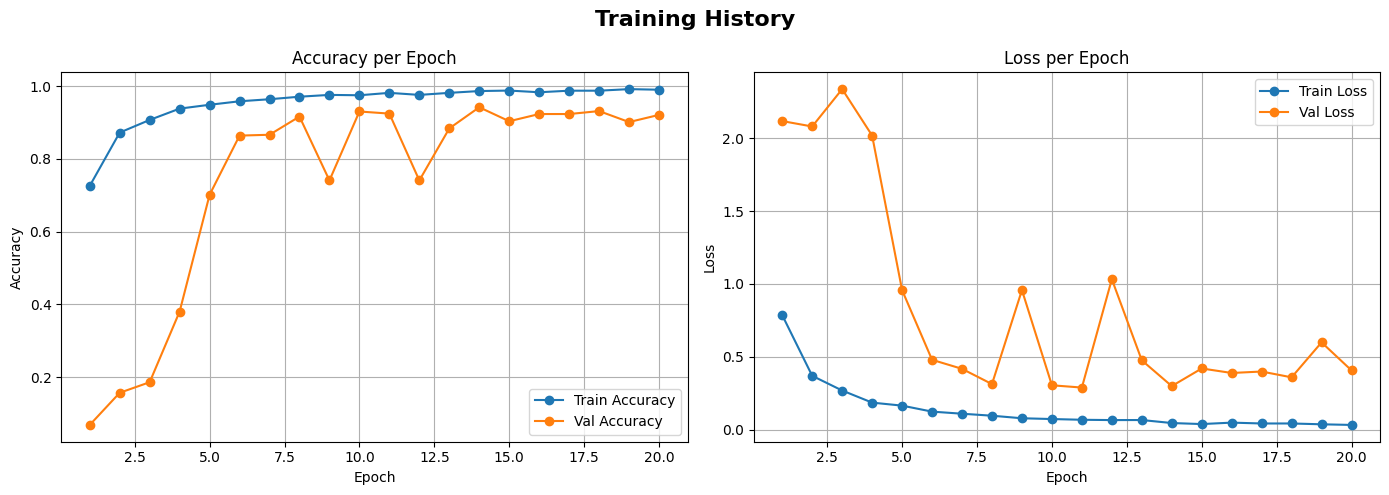

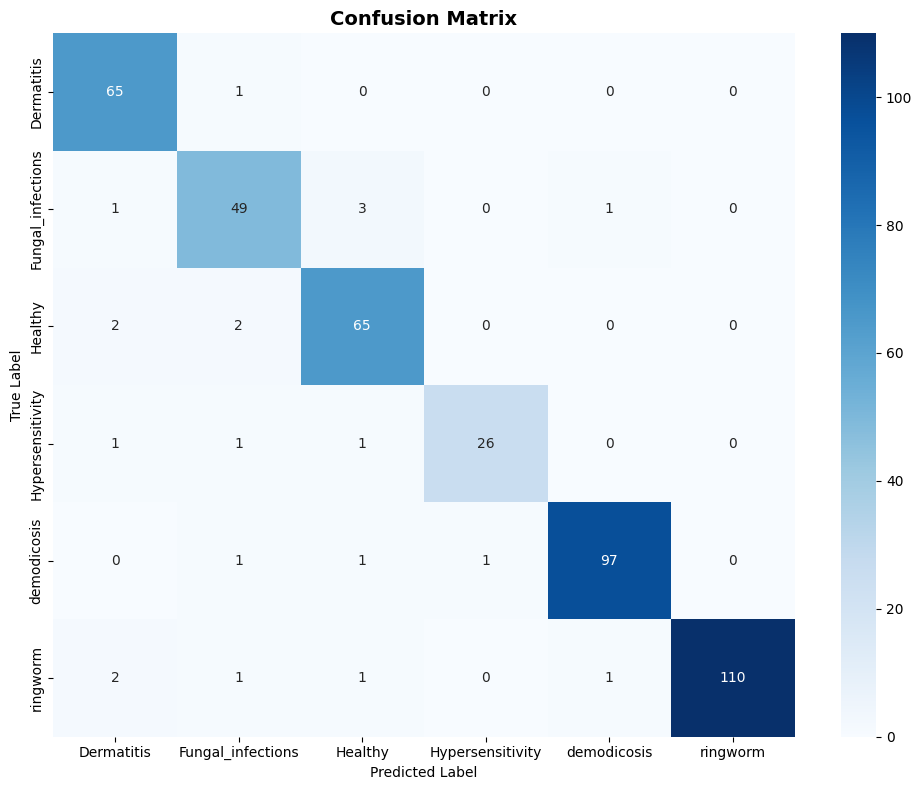

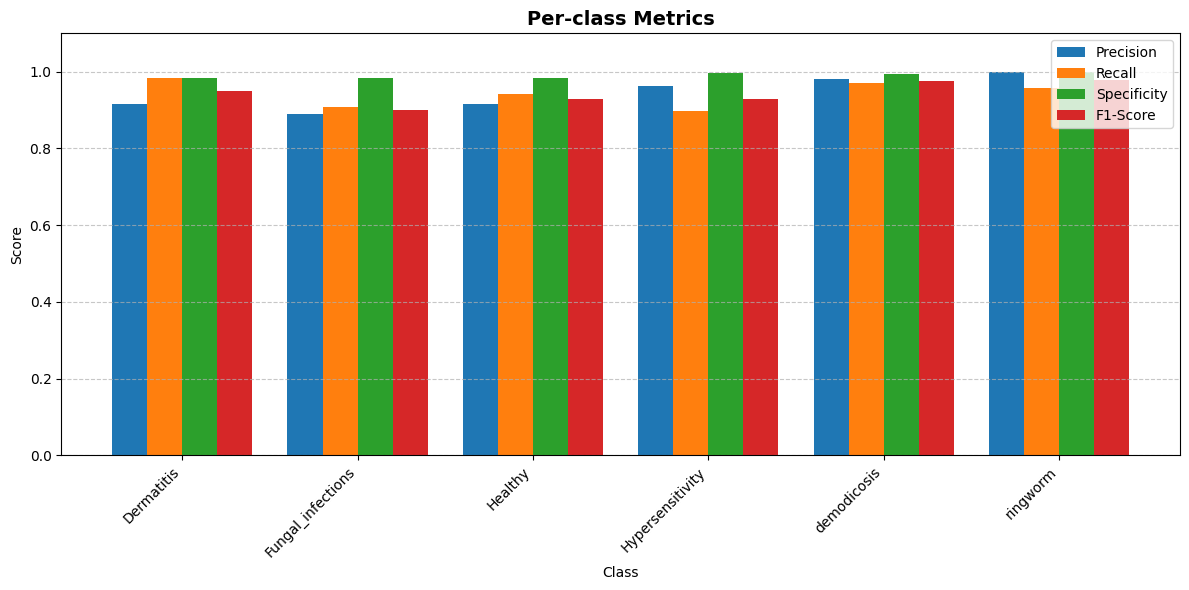

In [ ]:
if __name__ == '__main__':
    # Train the model
    print("Training model...")
    model, history = train_model(model, num_epochs=20)

    # Load best model weights 
    model.load_weights('best_model.keras')

    # Evaluate on test set
    print("Evaluating on test set...")
    evaluate_model(model, history)

Silakan pilih gambar penyakit kulit anjing (JPG/PNG)...


Saving images (1).jpg to images (1).jpg


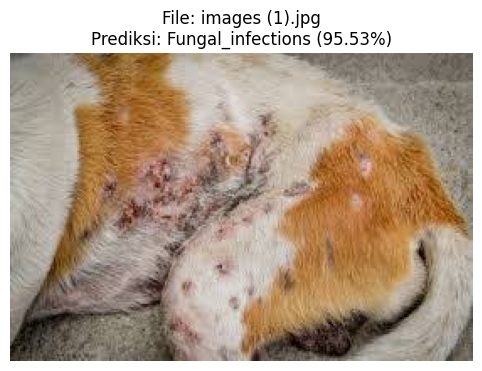

Hasil Analisis: Terdeteksi Fungal_infections dengan tingkat keyakinan 95.53%
--------------------------------------------------


In [ ]:
from google.colab import files
import tensorflow as tf
from tensorflow import keras
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import io

def predict_uploaded_image(model, class_names):
    # Definisi Transformasi (sesuai training)
    IMG_SIZE = (224, 224)

    # Upload File
    print("Silakan pilih gambar penyakit kulit anjing (JPG/PNG)...")
    uploaded = files.upload()

    if not uploaded:
        print("Upload dibatalkan.")
        return

    # Proses setiap gambar yang diupload
    for fn in uploaded.keys():
        # Load gambar dari memory
        img = Image.open(io.BytesIO(uploaded[fn])).convert('RGB')

        # Preprocessing
        img_resized = img.resize(IMG_SIZE)
        img_array = np.array(img_resized) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Inferensi
        y_pred_probs = model.predict(img_array, verbose=0)
        pred_index = np.argmax(y_pred_probs, axis=1)[0]
        confidence = y_pred_probs[0][pred_index] * 100

        predicted_class = class_names[pred_index]

        # Tampilkan Hasil
        plt.figure(figsize=(6, 4))
        plt.imshow(img)
        plt.title(f"File: {fn}\nPrediksi: {predicted_class} ({confidence:.2f}%)")
        plt.axis('off')
        plt.show()

        print(f"Hasil Analisis: Terdeteksi {predicted_class} dengan tingkat keyakinan {confidence:.2f}%")
        print("-" * 50)

predict_uploaded_image(model, class_names)

Silakan pilih gambar penyakit kulit anjing (JPG/PNG)...


Saving shutterstock_2138295357-scaled.jpg to shutterstock_2138295357-scaled (1).jpg


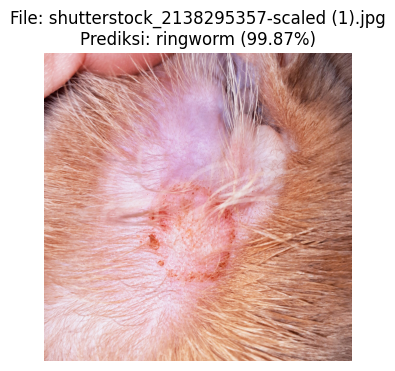

Hasil Analisis: Terdeteksi ringworm dengan tingkat keyakinan 99.87%
--------------------------------------------------


In [ ]:
from google.colab import files
import tensorflow as tf
from tensorflow import keras
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import io

def predict_uploaded_image(model, class_names):
    # Definisi Transformasi (sesuai training)
    IMG_SIZE = (224, 224)

    # Upload File
    print("Silakan pilih gambar penyakit kulit anjing (JPG/PNG)...")
    uploaded = files.upload()

    if not uploaded:
        print("Upload dibatalkan.")
        return

    # Proses setiap gambar yang diupload
    for fn in uploaded.keys():
        # Load gambar dari memory
        img = Image.open(io.BytesIO(uploaded[fn])).convert('RGB')

        # Preprocessing
        img_resized = img.resize(IMG_SIZE)
        img_array = np.array(img_resized) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Inferensi
        y_pred_probs = model.predict(img_array, verbose=0)
        pred_index = np.argmax(y_pred_probs, axis=1)[0]
        confidence = y_pred_probs[0][pred_index] * 100

        predicted_class = class_names[pred_index]

        # Tampilkan Hasil
        plt.figure(figsize=(6, 4))
        plt.imshow(img)
        plt.title(f"File: {fn}\nPrediksi: {predicted_class} ({confidence:.2f}%)")
        plt.axis('off')
        plt.show()

        print(f"Hasil Analisis: Terdeteksi {predicted_class} dengan tingkat keyakinan {confidence:.2f}%")
        print("-" * 50)

predict_uploaded_image(model, class_names)

Silakan pilih gambar penyakit kulit anjing (JPG/PNG)...


Saving photo_6282771679666704671_x.jpg to photo_6282771679666704671_x.jpg


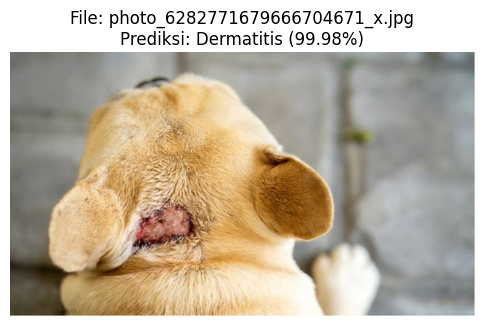

Hasil Analisis: Terdeteksi Dermatitis dengan tingkat keyakinan 99.98%
--------------------------------------------------


In [23]:
from google.colab import files
import tensorflow as tf
from tensorflow import keras
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import io

def predict_uploaded_image(model, class_names):
    # Definisi Transformasi (sesuai training)
    IMG_SIZE = (224, 224)

    # Upload File
    print("Silakan pilih gambar penyakit kulit anjing (JPG/PNG)...")
    uploaded = files.upload()

    if not uploaded:
        print("Upload dibatalkan.")
        return

    # Proses setiap gambar yang diupload
    for fn in uploaded.keys():
        # Load gambar dari memory
        img = Image.open(io.BytesIO(uploaded[fn])).convert('RGB')

        # Preprocessing
        img_resized = img.resize(IMG_SIZE)
        img_array = np.array(img_resized) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Inferensi
        y_pred_probs = model.predict(img_array, verbose=0)
        pred_index = np.argmax(y_pred_probs, axis=1)[0]
        confidence = y_pred_probs[0][pred_index] * 100

        predicted_class = class_names[pred_index]

        # Tampilkan Hasil
        plt.figure(figsize=(6, 4))
        plt.imshow(img)
        plt.title(f"File: {fn}\nPrediksi: {predicted_class} ({confidence:.2f}%)")
        plt.axis('off')
        plt.show()

        print(f"Hasil Analisis: Terdeteksi {predicted_class} dengan tingkat keyakinan {confidence:.2f}%")
        print("-" * 50)

predict_uploaded_image(model, class_names)

Silakan pilih gambar penyakit kulit anjing (JPG/PNG)...


Saving Hypersensitivity_1_jpg.rf.f415ba6336b66717bcc4f60395263ecb.jpg to Hypersensitivity_1_jpg.rf.f415ba6336b66717bcc4f60395263ecb.jpg


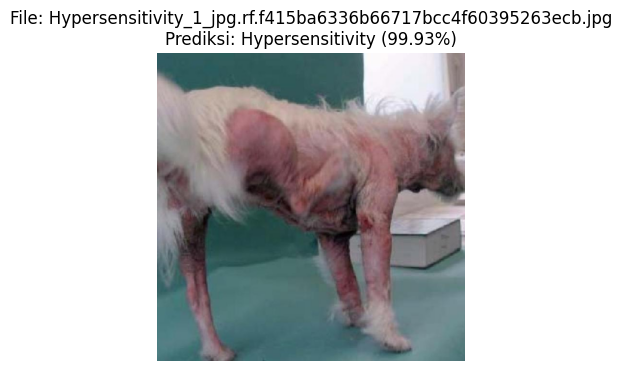

Hasil Analisis: Terdeteksi Hypersensitivity dengan tingkat keyakinan 99.93%
--------------------------------------------------


In [ ]:
from google.colab import files
import tensorflow as tf
from tensorflow import keras
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import io

def predict_uploaded_image(model, class_names):
    # Definisi Transformasi (sesuai training)
    IMG_SIZE = (224, 224)

    # Upload File
    print("Silakan pilih gambar penyakit kulit anjing (JPG/PNG)...")
    uploaded = files.upload()

    if not uploaded:
        print("Upload dibatalkan.")
        return

    # Proses setiap gambar yang diupload
    for fn in uploaded.keys():
        # Load gambar dari memory
        img = Image.open(io.BytesIO(uploaded[fn])).convert('RGB')

        # Preprocessing
        img_resized = img.resize(IMG_SIZE)
        img_array = np.array(img_resized) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Inferensi
        y_pred_probs = model.predict(img_array, verbose=0)
        pred_index = np.argmax(y_pred_probs, axis=1)[0]
        confidence = y_pred_probs[0][pred_index] * 100

        predicted_class = class_names[pred_index]

        # Tampilkan Hasil
        plt.figure(figsize=(6, 4))
        plt.imshow(img)
        plt.title(f"File: {fn}\nPrediksi: {predicted_class} ({confidence:.2f}%)")
        plt.axis('off')
        plt.show()

        print(f"Hasil Analisis: Terdeteksi {predicted_class} dengan tingkat keyakinan {confidence:.2f}%")
        print("-" * 50)

predict_uploaded_image(model, class_names)

Silakan pilih gambar penyakit kulit anjing (JPG/PNG)...


Saving 1-10-_jpg.rf.4cd37faa7c4842dc84c636c58d61b72d.jpg to 1-10-_jpg.rf.4cd37faa7c4842dc84c636c58d61b72d (1).jpg


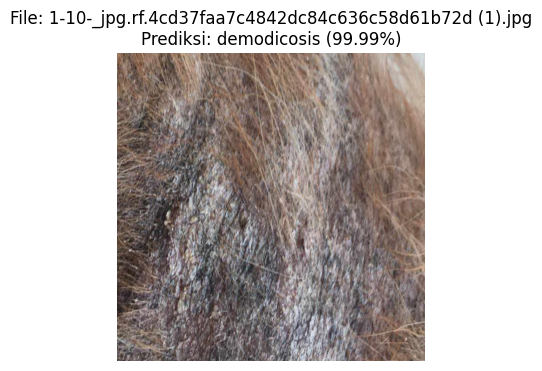

Hasil Analisis: Terdeteksi demodicosis dengan tingkat keyakinan 99.99%
--------------------------------------------------


In [ ]:
from google.colab import files
import tensorflow as tf
from tensorflow import keras
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import io

def predict_uploaded_image(model, class_names):
    # Definisi Transformasi (sesuai training)
    IMG_SIZE = (224, 224)

    # Upload File
    print("Silakan pilih gambar penyakit kulit anjing (JPG/PNG)...")
    uploaded = files.upload()

    if not uploaded:
        print("Upload dibatalkan.")
        return

    # Proses setiap gambar yang diupload
    for fn in uploaded.keys():
        # Load gambar dari memory
        img = Image.open(io.BytesIO(uploaded[fn])).convert('RGB')

        # Preprocessing
        img_resized = img.resize(IMG_SIZE)
        img_array = np.array(img_resized) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Inferensi
        y_pred_probs = model.predict(img_array, verbose=0)
        pred_index = np.argmax(y_pred_probs, axis=1)[0]
        confidence = y_pred_probs[0][pred_index] * 100

        predicted_class = class_names[pred_index]

        # Tampilkan Hasil
        plt.figure(figsize=(6, 4))
        plt.imshow(img)
        plt.title(f"File: {fn}\nPrediksi: {predicted_class} ({confidence:.2f}%)")
        plt.axis('off')
        plt.show()

        print(f"Hasil Analisis: Terdeteksi {predicted_class} dengan tingkat keyakinan {confidence:.2f}%")
        print("-" * 50)

predict_uploaded_image(model, class_names)

Silakan pilih gambar penyakit kulit anjing (JPG/PNG)...


Saving images (3).jpg to images (3).jpg


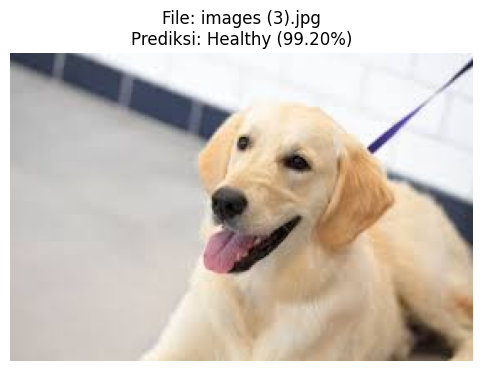

Hasil Analisis: Terdeteksi Healthy dengan tingkat keyakinan 99.20%
--------------------------------------------------


In [ ]:
from google.colab import files
import tensorflow as tf
from tensorflow import keras
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import io

def predict_uploaded_image(model, class_names):
    # Definisi Transformasi (sesuai training)
    IMG_SIZE = (224, 224)

    # Upload File
    print("Silakan pilih gambar penyakit kulit anjing (JPG/PNG)...")
    uploaded = files.upload()

    if not uploaded:
        print("Upload dibatalkan.")
        return

    # Proses setiap gambar yang diupload
    for fn in uploaded.keys():
        # Load gambar dari memory
        img = Image.open(io.BytesIO(uploaded[fn])).convert('RGB')

        # Preprocessing
        img_resized = img.resize(IMG_SIZE)
        img_array = np.array(img_resized) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Inferensi
        y_pred_probs = model.predict(img_array, verbose=0)
        pred_index = np.argmax(y_pred_probs, axis=1)[0]
        confidence = y_pred_probs[0][pred_index] * 100

        predicted_class = class_names[pred_index]

        # Tampilkan Hasil
        plt.figure(figsize=(6, 4))
        plt.imshow(img)
        plt.title(f"File: {fn}\nPrediksi: {predicted_class} ({confidence:.2f}%)")
        plt.axis('off')
        plt.show()

        print(f"Hasil Analisis: Terdeteksi {predicted_class} dengan tingkat keyakinan {confidence:.2f}%")
        print("-" * 50)

predict_uploaded_image(model, class_names)

In [19]:
dir = 'best_model.keras'

files.download(dir)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
# Simpan sebagai SavedModel
model.load_weights('best_model.keras')

saved_model_path = '/content/saved_model'
model.export(saved_model_path)

print(f"Model berhasil disimpan di: {saved_model_path}")

Saved artifact at '/content/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_175')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  137982666864016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137982666864784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137982666864208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137982666865360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137982666862672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137982666863056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137982540693776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137982540695120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137982540697040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137982540697232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137982

In [21]:
!zip -r saved_model.zip saved_model

files.download('saved_model.zip')

  adding: saved_model/ (stored 0%)
  adding: saved_model/saved_model.pb (deflated 91%)
  adding: saved_model/variables/ (stored 0%)
  adding: saved_model/variables/variables.index (deflated 79%)
  adding: saved_model/variables/variables.data-00000-of-00001 (deflated 7%)
  adding: saved_model/fingerprint.pb (stored 0%)
  adding: saved_model/assets/ (stored 0%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
!pip freeze > requirements.txt